In [1]:
import shap
import optuna
from sklearn import set_config
from xgboost import XGBRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

In [2]:
set_config(transform_output="pandas")

In [3]:
data = fetch_california_housing(as_frame=True)

In [4]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
data.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
data.feature_names, data.target_names

(['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 ['MedHouseVal'])

In this dataset, we have information regarding the demography (income, population, house occupancy) in the districts, the location of the districts (latitude, longitude), and general information regarding the house in the districts (number of rooms, number of bedrooms, age of the house). Since these statistics are at the granularity of the district, they corresponds to averages or medians.

In [7]:
x = data.data
y = data.target
x.shape, y.shape

((20640, 8), (20640,))

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## model

In [9]:
# model
xgb = XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.2, n_jobs=-1, random_state=42, gamma=0.05, objective="reg:squarederror", reg_lambda=50)

In [10]:
xgb.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [11]:
y_pred_train = xgb.predict(x_train)
y_pred_test = xgb.predict(x_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train rmse: {rmse_train:.4f} : R2 {r2_train:.4f}")
print(f"Test rmse: {rmse_test:.4f} : R2 {r2_test:.4f}")

Train rmse: 0.2899 : R2 0.9371
Test rmse: 0.4474 : R2 0.8472


## HP tuning

In [12]:
# tune the model

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 100),
        'gamma': trial.suggest_float('gamma', 0, 2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'n_jobs': -1,
        'random_state': 42,
        'objective': 'reg:squarederror'
    }

    model = XGBRegressor()
    model.set_params(**params)
    model.fit(x_train, y_train)

    # predict the test data
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    return r2

In [13]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=-1)

[I 2026-05-14 15:22:12,829] A new study created in memory with name: no-name-7a5be64e-094f-4756-9780-8c4885e7dfdc


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-14 15:22:14,499] Trial 2 finished with value: 0.8188215164076198 and parameters: {'learning_rate': 0.26415855662242166, 'n_estimators': 158, 'max_depth': 3, 'reg_lambda': 25.230366071725967, 'gamma': 0.209699013104526, 'subsample': 0.8468936691318101}. Best is trial 2 with value: 0.8188215164076198.
[I 2026-05-14 15:22:14,524] Trial 6 finished with value: 0.7859798205434425 and parameters: {'learning_rate': 0.06908190813588479, 'n_estimators': 194, 'max_depth': 3, 'reg_lambda': 39.60144786540523, 'gamma': 0.7966594969755876, 'subsample': 0.9789180373790156}. Best is trial 2 with value: 0.8188215164076198.
[I 2026-05-14 15:22:15,387] Trial 3 finished with value: 0.830774790891933 and parameters: {'learning_rate': 0.11503512816945201, 'n_estimators': 225, 'max_depth': 5, 'reg_lambda': 91.82935977299506, 'gamma': 0.7218866381052167, 'subsample': 0.8691391668508069}. Best is trial 3 with value: 0.830774790891933.
[I 2026-05-14 15:22:15,551] Trial 4 finished with value: 0.8213888

In [14]:
study.best_params

{'learning_rate': 0.18915672718771573,
 'n_estimators': 217,
 'max_depth': 8,
 'reg_lambda': 75.23739058781466,
 'gamma': 0.16820389514864836,
 'subsample': 0.8012400964103841}

In [15]:
study.best_value

0.8506849524910247

In [16]:
best_model = XGBRegressor(**study.best_params)
best_model.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [17]:
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train rmse: {rmse_train:.4f} : R2 {r2_train:.4f}")
print(f"Test rmse: {rmse_test:.4f} : R2 {r2_test:.4f}")

Train rmse: 0.2854 : R2 0.9391
Test rmse: 0.4445 : R2 0.8492


# shap

In [18]:
best_model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [19]:
explainer = shap.TreeExplainer(model=best_model, data=x_train)
explainer.expected_value

np.float64(2.0027479414191225)

In [20]:
shap_values = explainer(x_test)

 99%|===================| 4090/4128 [00:58<00:00]        

In [21]:
shap_values.shape

(4128, 8)

In [22]:
shap_values[0:3]

.values =
array([[-0.35609357,  0.01141786, -0.10991885,  0.01566079, -0.01606678,
        -0.21728724, -0.70431233, -0.03884085],
       [-0.34547917,  0.01239982, -0.09609551,  0.0108378 ,  0.01926139,
        -0.05062168, -0.7385882 ,  0.05768837],
       [ 0.15292158,  0.3541108 , -0.07373468,  0.08695582,  0.01287048,
         0.7588718 ,  0.29394926,  1.4917374 ]])

.base_values =
array([2.00274794, 2.00274794, 2.00274794])

.data =
array([[ 1.68120000e+00,  2.50000000e+01,  4.19220056e+00,
         1.02228412e+00,  1.39200000e+03,  3.87743733e+00,
         3.60600000e+01, -1.19010000e+02],
       [ 2.53130000e+00,  3.00000000e+01,  5.03938356e+00,
         1.19349315e+00,  1.56500000e+03,  2.67979452e+00,
         3.51400000e+01, -1.19460000e+02],
       [ 3.48010000e+00,  5.20000000e+01,  3.97715472e+00,
         1.18587747e+00,  1.31000000e+03,  1.36033229e+00,
         3.78000000e+01, -1.22440000e+02]])

## global plots

In [23]:
dict(zip(shap_values.feature_names, np.abs(shap_values.values).T.mean(axis=1)))

{'MedInc': np.float64(0.3078977346050644),
 'HouseAge': np.float64(0.04867758238435776),
 'AveRooms': np.float64(0.1587925859957192),
 'AveBedrms': np.float64(0.0278670648437244),
 'Population': np.float64(0.028352528191301483),
 'AveOccup': np.float64(0.19856074976976967),
 'Latitude': np.float64(0.6094915530107816),
 'Longitude': np.float64(0.4973205404174772)}

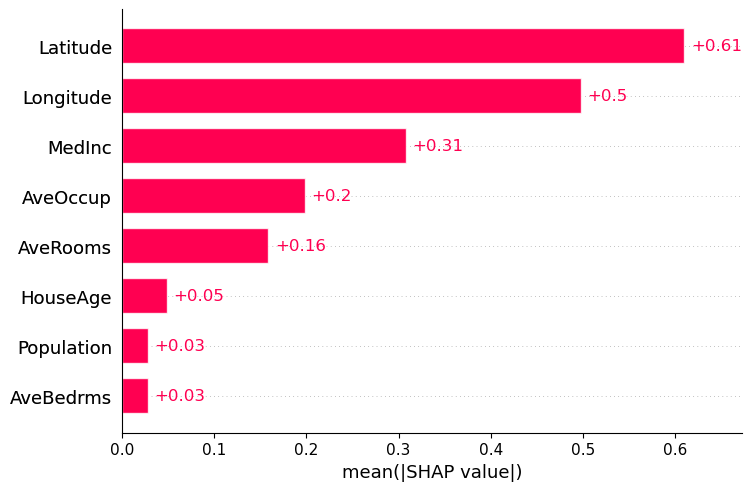

In [24]:
# global plot, on whole dataset
shap.plots.bar(shap_values)

In [25]:
shap_values.shape

(4128, 8)

In [26]:
dict(zip(best_model.feature_names_in_, best_model.feature_importances_))

{np.str_('MedInc'): np.float32(0.5606604),
 np.str_('HouseAge'): np.float32(0.060044196),
 np.str_('AveRooms'): np.float32(0.040789418),
 np.str_('AveBedrms'): np.float32(0.024795704),
 np.str_('Population'): np.float32(0.020342503),
 np.str_('AveOccup'): np.float32(0.12953934),
 np.str_('Latitude'): np.float32(0.07909515),
 np.str_('Longitude'): np.float32(0.084733315)}

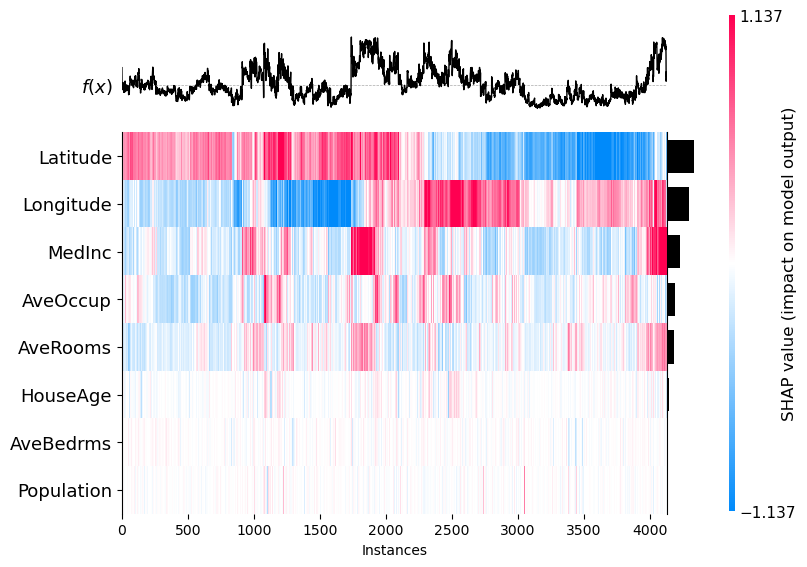

<Axes: xlabel='Instances'>

In [ ]:
# heatmap plot : global

shap.plots.heatmap(shap_values)

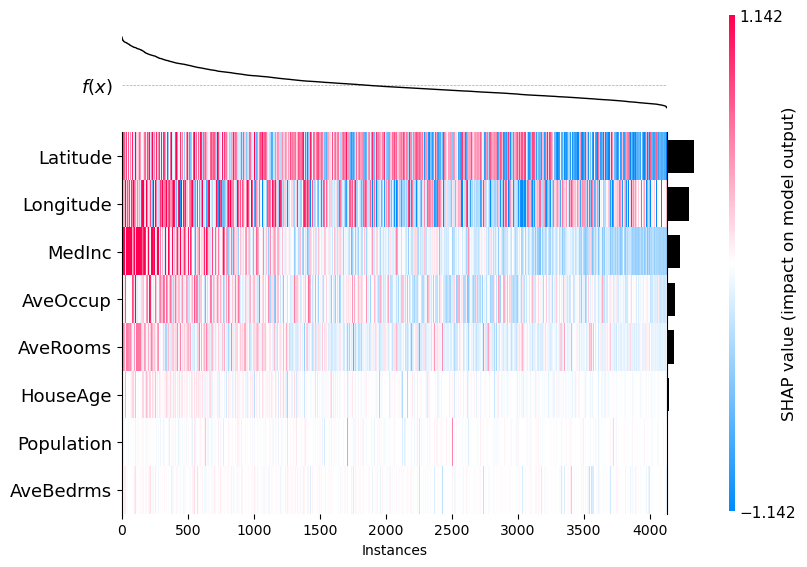

<Axes: xlabel='Instances'>

In [27]:
shap.plots.heatmap(shap_values, instance_order=shap_values.sum(1))

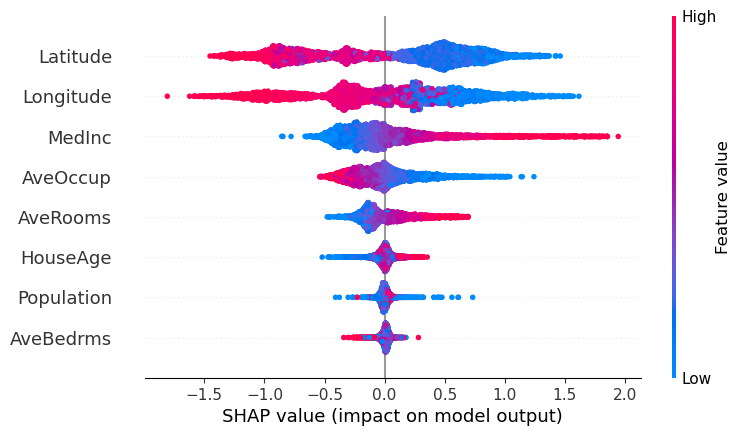

In [28]:
# summary plot : global

shap.plots.beeswarm(shap_values)

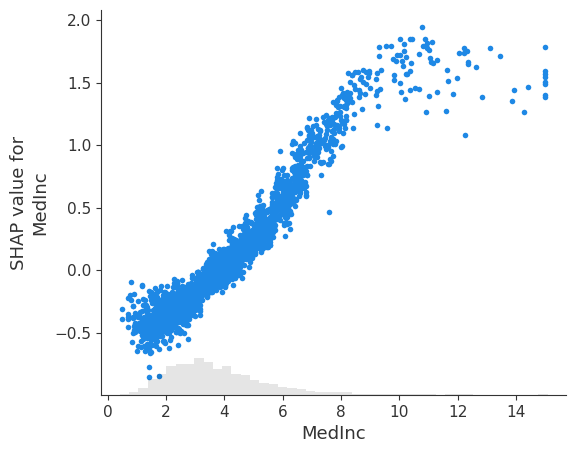

In [29]:
# dependency plot : global
shap.plots.scatter(shap_values[:, "MedInc"])

<Axes: xlabel='MedInc', ylabel='Count'>

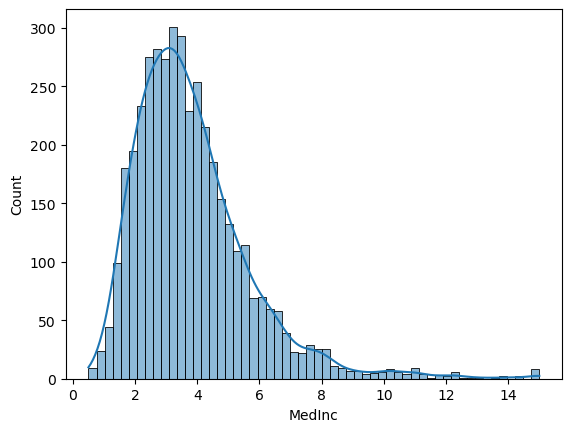

In [30]:
import seaborn as sns
sns.histplot(x_test["MedInc"], kde=True)

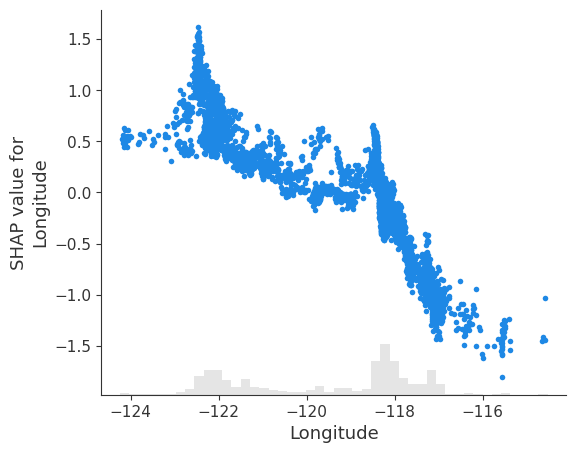

In [31]:
shap.plots.scatter(shap_values[:, "Longitude"])

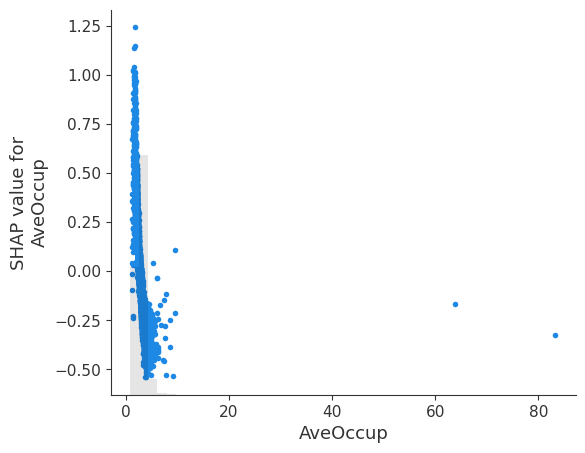

In [32]:
shap.plots.scatter(shap_values[:, "AveOccup"])

In [33]:
shap_values[x_test[['AveOccup']].reset_index(drop=True).query("AveOccup < 40").index.values, "AveOccup"]
# shap_values[:, "AveOccup"]

.values =
array([-0.21728724, -0.05062168,  0.7588718 , ...,  0.01872949,
       -0.00663656, -0.31877868], shape=(4126,))

.base_values =
array([2.00274794, 2.00274794, 2.00274794, ..., 2.00274794, 2.00274794,
       2.00274794], shape=(4126,))

.data =
array([3.87743733, 2.67979452, 1.36033229, ..., 2.79049296, 2.58860759,
       3.72991071], shape=(4126,))

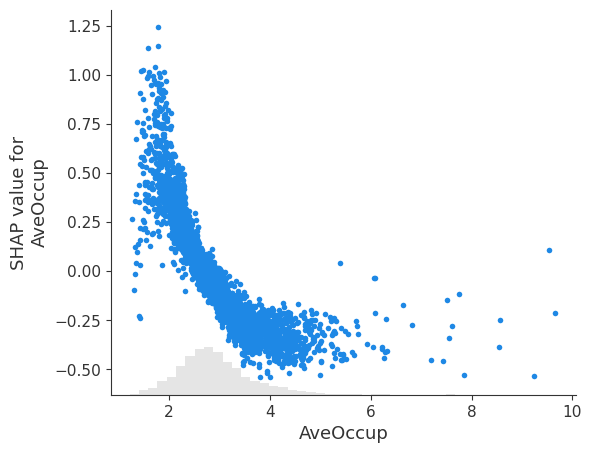

In [34]:
shap.plots.scatter(shap_values[x_test[['AveOccup']].reset_index(drop=True).query("AveOccup < 40").index.values, "AveOccup"])

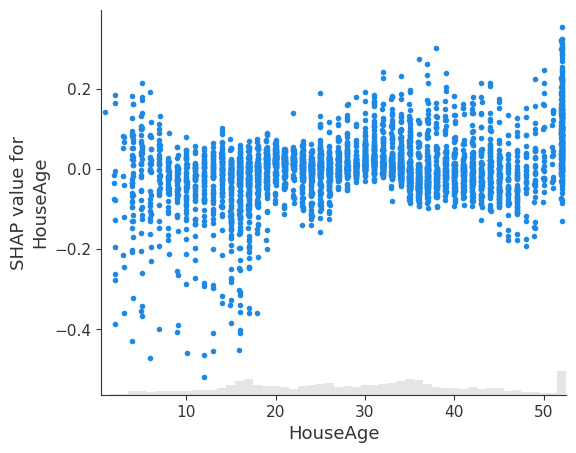

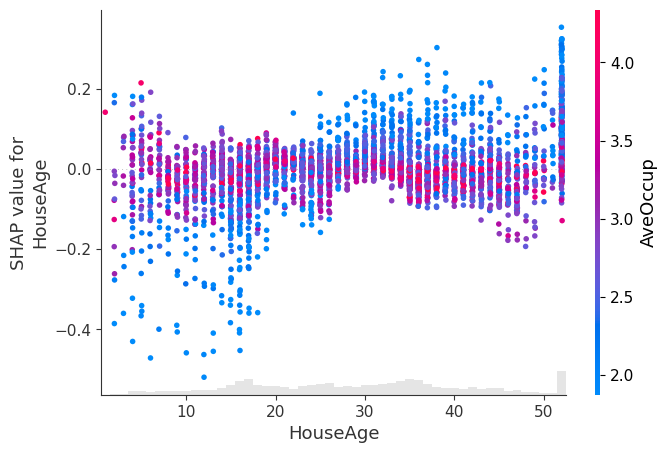

In [36]:
# scatter plot with interaction

shap.plots.scatter(shap_values[:, "HouseAge"])
shap.plots.scatter(shap_values[:, "HouseAge"], color=shap_values)

In [61]:
test_case = x_test.sample(1)
explained_row = explainer(test_case)
explained_row[0]

.values =
array([-0.44154183,  0.00167186, -0.10280294,  0.01986913, -0.0193685 ,
       -0.06689239, -0.70323455,  0.17129412])

.base_values =
np.float64(2.0027479414191225)

.data =
array([ 1.78410000e+00,  3.40000000e+01,  5.17134831e+00,  9.94382022e-01,
        1.01900000e+03,  2.86235955e+00,  3.70300000e+01, -1.20610000e+02])

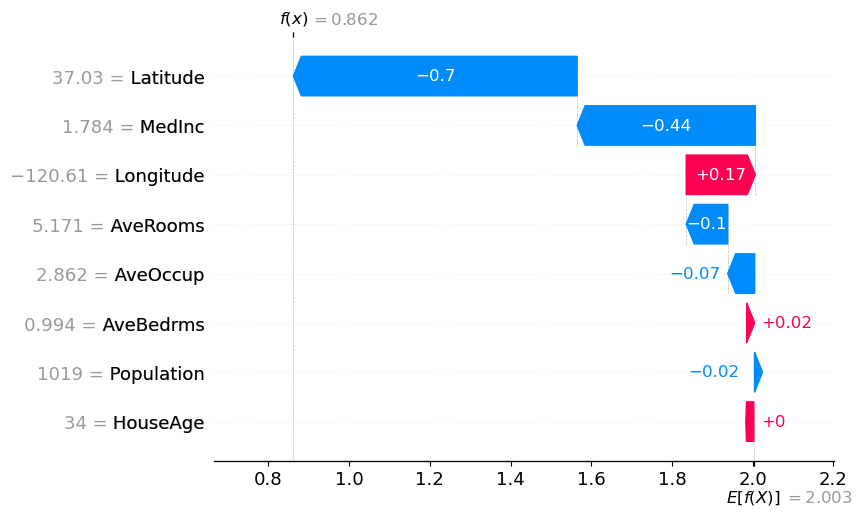

In [62]:
# waterfall plot : local
shap.plots.waterfall(explained_row[0])

In [64]:
(explained_row.values[0].sum() + explained_row.base_values[0]).round(3)

np.float64(0.862)

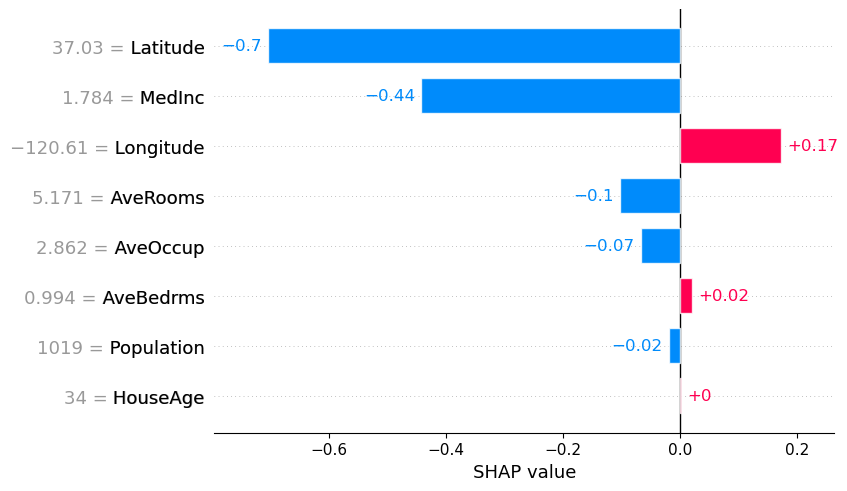

In [92]:
shap.plots.bar(explained_row[0])

In [66]:
# force plot : local
shap.plots.initjs()
shap.plots.force(explained_row[0])

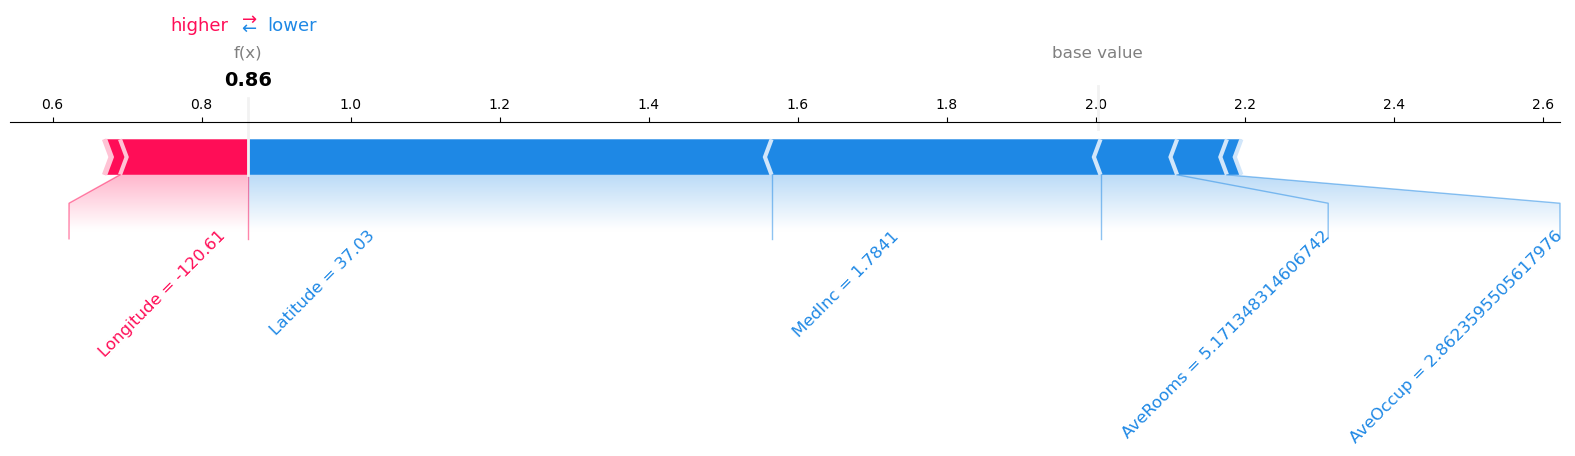

In [76]:
shap.plots.force(explained_row[0], matplotlib=True, text_rotation=45)
plt.show()

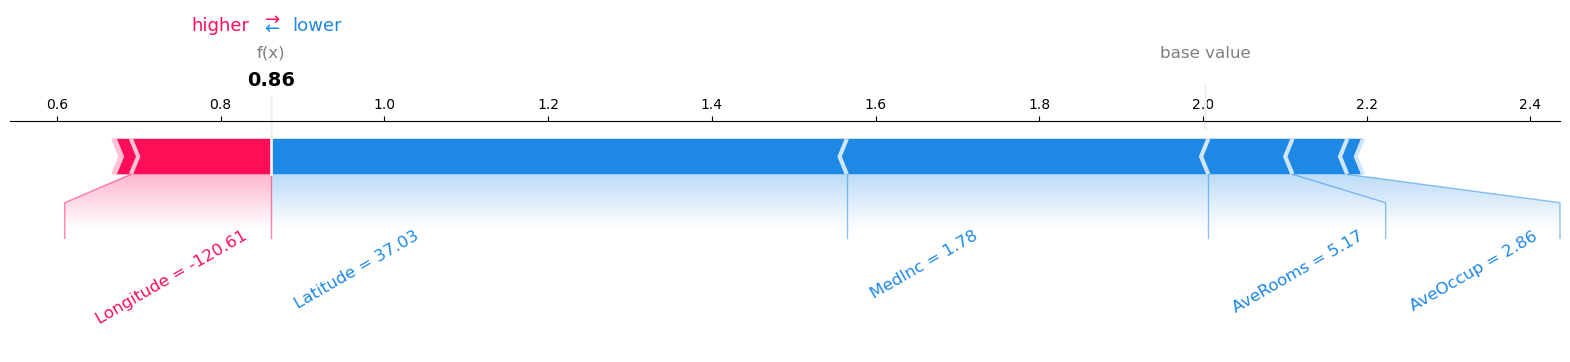

In [ ]:
shap.plots.force(explained_row[0], features=explained_row.data[0].round(2), matplotlib=True, text_rotation=30)
plt.show()